In [1]:
import torch
import math
import numpy as np 
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

from src.gpt.model import GPT2
from src.gpt.tokenizer import BPETokenizer

In [2]:
device      = "cuda" if torch.cuda.is_available() else "cpu"
data_path   = "data/tiny_shakespeare/train.bin"
merges_path = "data/tiny_shakespeare/merges.txt"

In [3]:
tokenizer = BPETokenizer().load(merges_path)
data = np.memmap(data_path,dtype=np.uint16, mode="r")
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

In [4]:
tokenizer.show_merges()

256: 'e' + ' ' -> 'e '
257: 't' + 'h' -> 'th'
258: 't' + ' ' -> 't '
259: 's' + ' ' -> 's '
260: 'd' + ' ' -> 'd '
261: ',' + ' ' -> ', '
262: 'o' + 'u' -> 'ou'
263: 'e' + 'r' -> 'er'
264: 'i' + 'n' -> 'in'
265: 'y' + ' ' -> 'y '
266: 'a' + 'n' -> 'an'
267: ':' + '\n' -> ':\n'
268: 'o' + 'r' -> 'or'
269: 'o' + ' ' -> 'o '
270: 'e' + 'n' -> 'en'
271: '\n' + '\n' -> '\n\n'
272: 'a' + 'r' -> 'ar'
273: ' ' + 'th' -> ' th'
274: 'o' + 'n' -> 'on'
275: 'l' + 'l' -> 'll'
276: 'h' + 'a' -> 'ha'
277: ',' + '\n' -> ',\n'
278: '.' + '\n\n' -> '.\n\n'
279: 'i' + 's ' -> 'is '
280: 'e' + 's' -> 'es'
281: 'y' + 'ou' -> 'you'
282: ' ' + 's' -> ' s'
283: 't' + 'o ' -> 'to '
284: 'an' + 'd ' -> 'and '
285: 'o' + 'w' -> 'ow'
286: 'e' + 'a' -> 'ea'
287: ' ' + 'm' -> ' m'
288: ' ' + 'w' -> ' w'
289: 'o' + 'f' -> 'of'
290: ' ' + 'h' -> ' h'
291: 'in' + 'g' -> 'ing'
292: 'o' + 'm' -> 'om'
293: ' ' + 'a' -> ' a'
294: 'c' + 'h' -> 'ch'
295: 'th' + 'e ' -> 'the '
296: 's' + 't' -> 'st'
297: ' ' + 'b' -> ' b'
29

In [5]:
train_data[:100]

memmap([ 726, 1178,  267,  984,  655,  538,  606,   99, 1027,  719,  102,
         333,  368,  261,  525,  690,  854,  278,   65,  275,  969,  112,
         574,  261,  854,  994, 1178,  267, 1034,  420,  808,  449,  403,
         118,  340,  330,  728,  283,  404,  256,  773,  399,  355,  109,
         559,  353,   65,  275,  267,   82,  280,  403,  118,  424,  370,
         449,  403,  118,  424,  994, 1178,  267,   70,  299,  296,  261,
         534,  500,   32,   67,   97,  105,  505,  786,  531,  505,  279,
         294,  105,  760,   32,  270,  101,  328,  699,  987,  515,  321,
         278,   65,  275,  267,  851,  500,   39,  392,  538,  500,  536,
         994], dtype=uint16)

In [6]:
### Config
vocab_size = len(tokenizer.vocab)
batch_size = 16
n_embed    = 256
n_head     = 8
n_layer    = 6
block_size = 500
dropout    = 0.3
eval_iters = 25


In [7]:
def get_batch(data, block_size, batch_size, device):
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i   : i+block_size].astype(np.int64))   for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1 : i+1+block_size].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

In [8]:
@torch.no_grad()
def estimate_loss(model):
    model.eval()
    splits = {"train": train_data, "val": val_data}
    out = {}
    for split, data in splits.items():
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(data, block_size, batch_size, device)
            _, loss = model(xb, yb)
            losses[k] = loss
        out[split] = losses.mean().item()
    model.train()
    return out 

In [9]:
model = GPT2(
    vocab_size,
    n_embed,
    n_head,
    n_layer,
    block_size,
    dropout
).to(device)

params_count = sum([p.numel() for p in model.parameters()])
print(f"{params_count/1e6:.2f}M Parameters")

5.48M Parameters


In [10]:
# Initializing the Optimizer and Context Manager

max_steps = 3000
eval_interval = 200


max_lr = 1e-3
min_lr = 1e-4
warmup_steps = max_steps // 20 # 5% of max_steps

optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr)
ctx = torch.autocast(device, dtype=torch.bfloat16)


def get_lr(step):
    if step < warmup_steps: # Linear warmup
        return max_lr * (step+1) / warmup_steps
    ratio = (step - warmup_steps) / (max_steps - warmup_steps) # [0 - 1.0]
    # 1/2 * (1 + cos(pi*ratio)) -> [1, 0]
    coeff = 0.5 * (1.0 + math.cos(math.pi * ratio))
    return min_lr + coeff * (max_lr - min_lr)



In [11]:
history = {"step": [], "train": [], "val": [], "lr": []}


pbar = tqdm(range(max_steps), desc="GPT2 training", unit="steps")

for step in pbar:

    lr = get_lr(step)
    for group in optimizer.param_groups:
        group["lr"] = lr

    if step % eval_interval == 0 or step == max_steps - 1:
        losses = estimate_loss(model)
        # Logging
        history["step"].append(step)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        history["lr"].append(lr)

        pbar.write(
            f"step {step:5d} | train {losses['train']:.4f} | "
            "val {losses['val']:.4f} | lr {lr:.2e}"
        )

        pbar.set_postfix({
            "Train": f"{losses['train']:.4f}", 
            "val"  : f"{losses['val']:.4f}",
            "lr"   : f"{lr:.2e}"
        })

    xb, yb = get_batch(train_data, block_size, batch_size, device)

    with ctx:
        logits, loss = model(xb, yb)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

GPT2 training: 100%|██████████| 3000/3000 [10:13<00:00,  4.89steps/s, Train=3.2746, val=4.3976, lr=1.00e-04] 


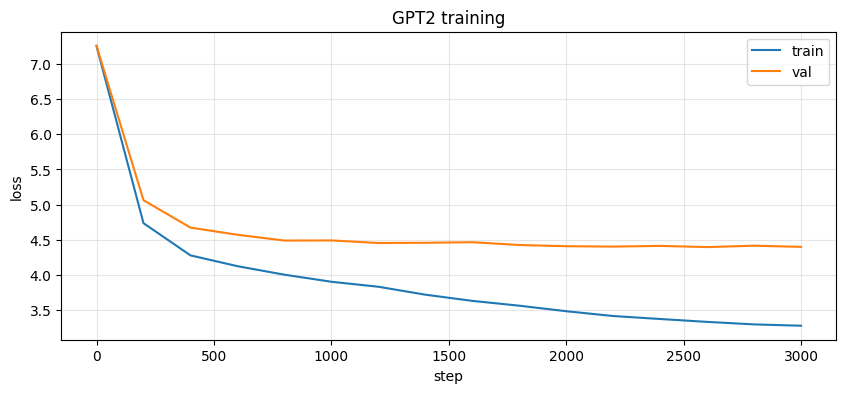

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history["step"], history["train"], label="train")
plt.plot(history["step"], history["val"], label="val")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("GPT2 training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, block_size):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]        # crop to context window
        logits, _ = model(idx_cond)            # (B, T, V)
        logits = logits[:, -1, :]              # last step only -> (B, V)
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)
        idx = torch.cat([idx, idx_next], dim=1)
    return idx

@torch.no_grad()
def generate_text(model, tokenizer, prompt, max_new_tokens, block_size, device):
    model.eval()
    ids = tokenizer.encode(prompt)                              # list[int]
    idx = torch.tensor([ids], dtype=torch.long, device=device)  # (1, T)
    out = generate(model, idx, max_new_tokens, block_size)      # (1, T+new)
    return tokenizer.decode(out[0].tolist())   

In [14]:
start = tokenizer.encode("\n")
idx = torch.tensor([start], dtype=torch.long, device=device)

generate(model, idx, max_new_tokens=100, block_size=block_size)

tensor([[  10,  307,  299,   32,  598,   32,  466,  102,  342,   98,  911,  115,
          561,  121,  302,  361,  313,  102,  317,  258,  356,  703,  329,  360,
          270,  400, 1010,  357,  678,  263, 1041,   84,  414,  381,  298,   58,
          434,  942,  771,  686,  304,  435,  102,  766,  664,  345,  264,  298,
         1025,   10,  569,  109,  526,  264,  259,  311,  104,  323,  290,  762,
           10,   71,  105,  485,  478,  340,  363,  302,   99,  380,  100,  323,
          259,  553,  102,  256,  279,  327,  328, 1118,  407,   10,   87,  401,
          265,  119,  401,  435,   99,  333,  294,  632,  256,  529,   45,  464,
          575,  329,   71,  108,  262]], device='cuda:0')

In [23]:
text = generate_text(model, tokenizer, "\n", 1000, block_size, device)
print(text)



RUTUS:
We have pass'd on,
Rome, ined tongues ning in their
dear by the chance of against to proge.

COMINIUS:
Pray, sir, and never mer.

CORIOLANUS:
No, She ock of our
Be true them
What as you not speak.

MENENIUS:
You place you do remem to preport.

CORIOLANUS:
Now, four know at our answer, pon't!

Citizens:
That you deness, and ineseech you!
Fill, sir, gown.

Third Citizensul
Let's gods me therefore you somans, he ly.

CORIOLANUS:
Well, sir, to think, on
Offough you have ople
Thank'not away deserdece:
You have anceives are false thank it were speak. Selse his honour'd home,
And trates well us bears the member
Rome to say 'tis now we do not in his falft,
Whome, he prick so pt out grate
We have hatar and that clouble to me: so piti'd, I saway have to ans
Aufidius?
We have you are to us to't,--

Citizen:
A comethese fast the heart procurse:
'Sawdeed!

Stesty say you, sir, ife the time and is that, or say the time
CORIOLANUS:
I say, let's marry will most people--
They to ging your compe